In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp, wasserstein_distance
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

In [55]:
df_h = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\dev\pasantia\analisis_detallado_hyades.csv")   
df_c = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\dev\pasantia\coma_sample.csv")
df_a = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\data\datos_shell\gaia_parallax5_10_fidelity.csv") 
df_h = df_h[df_h["phot_g_mean_mag"]<18].copy() 
df_c = df_c[df_c["phot_g_mean_mag"]<18].copy() 
df_a = df_a[df_a["phot_g_mean_mag"]<18].copy()  

In [64]:
def restrict_reference_like_cluster(
    cluster_df,
    gaia_df,
    cols=("parallax", "phot_g_mean_mag", "pmra", "pmdec"),
    q_low=0.05,
    q_high=0.95,
    pad_frac=0.25,
):
    mask = np.ones(len(gaia_df), dtype=bool)

    for col in cols:
        if col not in cluster_df.columns or col not in gaia_df.columns:
            continue

        lo = cluster_df[col].quantile(q_low)
        hi = cluster_df[col].quantile(q_high)

        width = hi - lo
        lo -= pad_frac * width
        hi += pad_frac * width

        mask &= gaia_df[col].between(lo, hi)

    return gaia_df.loc[mask].copy()

In [84]:
df_a_like_h = restrict_reference_like_cluster(
    df_h,
    df_a,
    cols=("parallax", "pmra", "pmdec"),
)

df_a_like_c = restrict_reference_like_cluster(
    df_c,
    df_a,
    cols=("parallax", "pmra", "pmdec"),
)

print(len(df_a_like_h), len(df_a_like_c))

7302 3748


In [85]:
error_cols = ["parallax_error", "pmra_error", "pmdec_error"]


def get_log_errors(df, cols=error_cols):
    """
    Devuelve un DataFrame con log10 de los errores,
    usando solo valores positivos y finitos.
    """
    out = df[cols].copy()

    for col in cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    mask = np.ones(len(out), dtype=bool)

    for col in cols:
        mask &= np.isfinite(out[col].values)
        mask &= out[col].values > 0

    out = out.loc[mask].copy()

    for col in cols:
        out[f"log10_{col}"] = np.log10(out[col])

    return out

In [86]:
h_err = get_log_errors(df_h)
c_err = get_log_errors(df_c)

a_like_h_err = get_log_errors(df_a_like_h)
a_like_c_err = get_log_errors(df_a_like_c)

In [87]:
def bootstrap_1d_test(
    cluster_df,
    gaia_df,
    col,
    n_boot=10,
    seed=42,
    statistic="ks",
):
    """
    Prueba empírica 1D.

    H0: la muestra del cúmulo proviene de la distribución empírica de Gaia.

    statistic:
        "ks"          -> estadístico D de Kolmogorov-Smirnov
        "wasserstein" -> distancia Wasserstein
    """

    rng = np.random.default_rng(seed)

    x_obs = cluster_df[f"log10_{col}"].dropna().values
    x_gaia = gaia_df[f"log10_{col}"].dropna().values

    n = len(x_obs)

    if statistic == "ks":
        t_obs = ks_2samp(x_obs, x_gaia).statistic

        def stat_fun(x):
            return ks_2samp(x, x_gaia).statistic

    elif statistic == "wasserstein":
        t_obs = wasserstein_distance(x_obs, x_gaia)

        def stat_fun(x):
            return wasserstein_distance(x, x_gaia)

    else:
        raise ValueError("statistic debe ser 'ks' o 'wasserstein'.")

    t_boot = np.empty(n_boot)

    for i in range(n_boot):
        x_boot = rng.choice(x_gaia, size=n, replace=True)
        t_boot[i] = stat_fun(x_boot)

    p_value = (np.sum(t_boot >= t_obs) + 1) / (n_boot + 1)

    result = {
        "variable": col,
        "n_cluster": n,
        "statistic": statistic,
        "T_obs": t_obs,
        "p_value": p_value,
        "T_boot_median": np.median(t_boot),
        "T_boot_95": np.quantile(t_boot, 0.95),
        "T_boot_99": np.quantile(t_boot, 0.99),
    }

    return result, t_boot

In [88]:
def run_all_1d_tests(cluster_df, gaia_df, cluster_name, n_boot=10):
    rows = []

    for col in error_cols:
        for stat in ["ks", "wasserstein"]:
            res, _ = bootstrap_1d_test(
                cluster_df=cluster_df,
                gaia_df=gaia_df,
                col=col,
                n_boot=n_boot,
                seed=42,
                statistic=stat,
            )

            res["cluster"] = cluster_name
            rows.append(res)

    return pd.DataFrame(rows)

In [89]:
results_h = run_all_1d_tests(h_err, a_like_h_err, "Hyades", n_boot=50)
results_c = run_all_1d_tests(c_err, a_like_c_err, "Coma", n_boot=50)

results = pd.concat([results_h, results_c])
results

,variable,n_cluster,statistic,T_obs,p_value,T_boot_median,T_boot_95,T_boot_99,cluster
0,parallax_error,438,ks,0.120442,0.019608,0.039692,0.058528,0.065654,Hyades
1,parallax_error,438,wasserstein,0.104610,0.019608,0.021330,0.035614,0.040641,Hyades
2,pmra_error,438,ks,0.194405,0.019608,0.040743,0.062352,0.067755,Hyades
3,pmra_error,438,wasserstein,0.175590,0.019608,0.022797,0.038145,0.046217,Hyades
4,pmdec_error,438,ks,0.081590,0.019608,0.041555,0.059201,0.070895,Hyades
5,pmdec_error,438,wasserstein,0.067205,0.019608,0.021375,0.037530,0.041618,Hyades
0,parallax_error,242,ks,0.107394,0.039216,0.052755,0.080965,0.100802,Coma
1,parallax_error,242,wasserstein,0.096220,0.019608,0.034951,0.063478,0.071164,Coma
2,pmra_error,242,ks,0.119036,0.019608,0.053611,0.083857,0.099684,Coma
3,pmra_error,242,wasserstein,0.096019,0.019608,0.035786,0.062425,0.072735,Coma


In [92]:
alpha = 0.05

results["compatible_con_gaia"] = results["p_value"] < alpha

results[
    [
        "cluster",
        "variable",
        "statistic",
        "n_cluster",
        "T_obs",
        "T_boot_95",
        "T_boot_99",
        "p_value",
        "compatible_con_gaia",
    ]
]

,cluster,variable,statistic,n_cluster,T_obs,T_boot_95,T_boot_99,p_value,compatible_con_gaia
0,Hyades,parallax_error,ks,438,0.120442,0.058528,0.065654,0.019608,True
1,Hyades,parallax_error,wasserstein,438,0.104610,0.035614,0.040641,0.019608,True
2,Hyades,pmra_error,ks,438,0.194405,0.062352,0.067755,0.019608,True
3,Hyades,pmra_error,wasserstein,438,0.175590,0.038145,0.046217,0.019608,True
4,Hyades,pmdec_error,ks,438,0.081590,0.059201,0.070895,0.019608,True
5,Hyades,pmdec_error,wasserstein,438,0.067205,0.037530,0.041618,0.019608,True
0,Coma,parallax_error,ks,242,0.107394,0.080965,0.100802,0.039216,True
1,Coma,parallax_error,wasserstein,242,0.096220,0.063478,0.071164,0.019608,True
2,Coma,pmra_error,ks,242,0.119036,0.083857,0.099684,0.019608,True
3,Coma,pmra_error,wasserstein,242,0.096019,0.062425,0.072735,0.019608,True


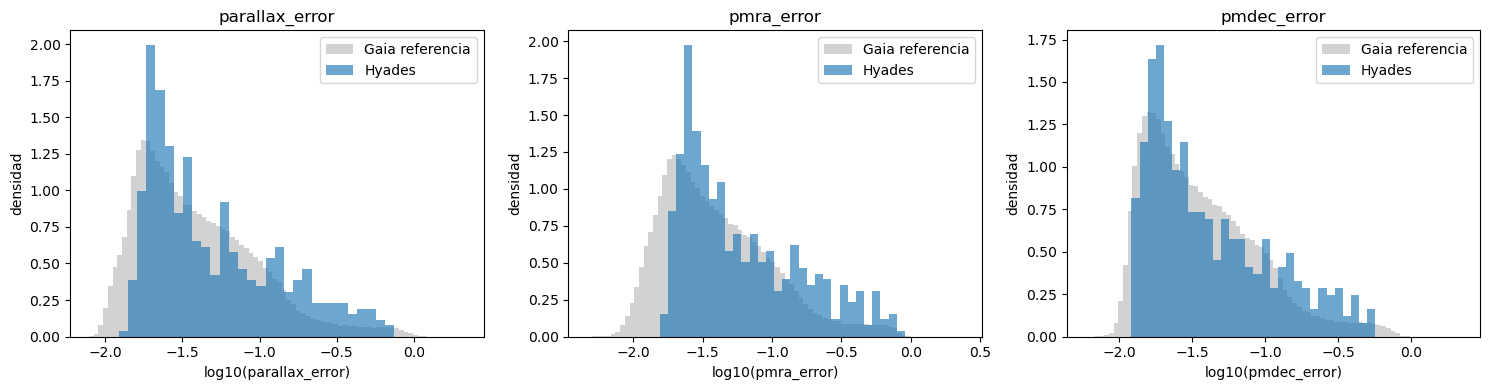

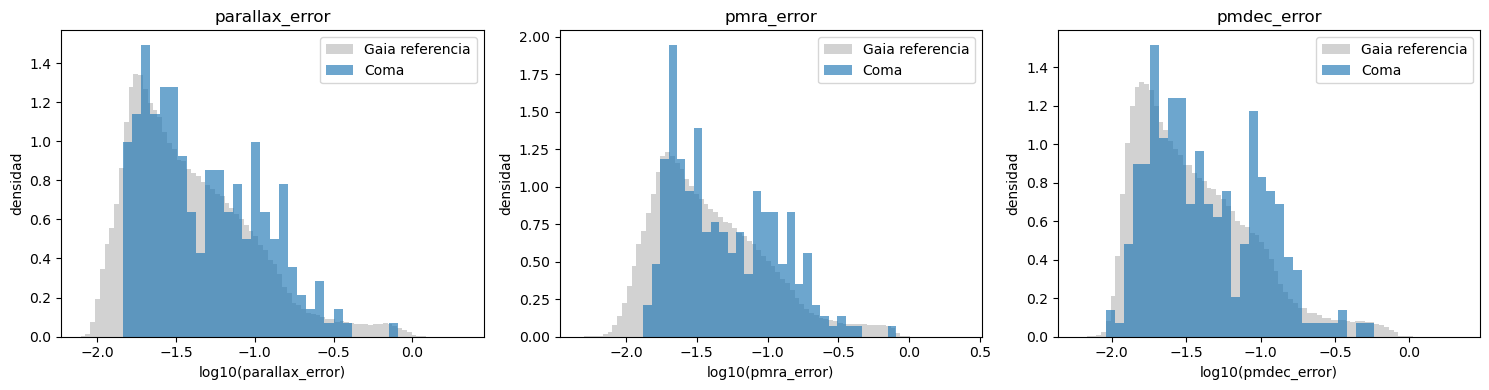

In [91]:

def plot_error_distributions(cluster_df, gaia_df, cluster_name):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, col in zip(axes, error_cols):
        x_gaia = gaia_df[f"log10_{col}"].dropna().values
        x_cl = cluster_df[f"log10_{col}"].dropna().values

        ax.hist(
            x_gaia,
            bins=80,
            density=True,
            alpha=0.35,
            label="Gaia referencia",
            color="gray",
        )

        ax.hist(
            x_cl,
            bins=30,
            density=True,
            alpha=0.65,
            label=cluster_name,
        )

        ax.set_xlabel(f"log10({col})")
        ax.set_ylabel("densidad")
        ax.set_title(col)
        ax.legend()

    plt.tight_layout()
    plt.show()


plot_error_distributions(h_err, a_err, "Hyades")
plot_error_distributions(c_err, a_err, "Coma")